# 01 · Exploración del dataset — Miniproyecto 1 TinyML (UAO 2026-2)

**Proyecto Bartender.** 60 tomas del IMU de un Arduino Nano 33 BLE Sense,
exportadas desde Edge Impulse en formato **CBOR** (no JSON).

## Qué hace este notebook

1. Decodifica los 60 `.cbor` y arma la tabla por toma y por clase:
   número de tomas, **duración real medida** y número de muestras.
2. Grafica las 6 clases (acelerómetro, giroscopio y magnetómetro).
3. Mide la energía por eje y por clase → evidencia para **descartar `mag*`**
   ([issue #5](https://github.com/caesar-dat-com/miniproyecto1-tinyml/issues/5)).
4. Mide el espectro por clase → de ahí sale el **tamaño de ventana**.
5. Cuenta **cuántas ventanas aporta cada clase** y cuánto desbalancea `remover`
   ([issue #4](https://github.com/caesar-dat-com/miniproyecto1-tinyml/issues/4)).

## Qué hay que subir a Colab

La carpeta `edge-impulse/dataset/` del repo (o un `.zip` de ella), con:

```
dataset/
  info-6clases.labels          <- etiquetas buenas: 6 clases × 10 tomas
  training/*.cbor              <- 60 tomas
```

> ⚠️ **No uses `info.labels`.** Ese archivo trae 60 etiquetas distintas, una por
> toma, así que entrenarías 60 clases de una muestra cada una
> ([issue #1](https://github.com/caesar-dat-com/miniproyecto1-tinyml/issues/1)).
> Por eso todo el notebook lee `info-6clases.labels`.

## Dos datos que no se negocian

| | |
|---|---|
| Frecuencia de muestreo | `interval_ms = 16.0` → **62,5 Hz**, no 100 Hz |
| Ventana de 2 s | **125 muestras**, no 200 y no las 100 del ejemplo de clase |


## 1 · Instalación

In [1]:
# --- Celda de instalacion: ejecutar primero en Colab ---
# Colab ya trae numpy, scipy, scikit-learn, matplotlib, pandas y tensorflow.
# Lo unico que falta es cbor2, porque el export de Edge Impulse es .cbor (NO .json).
%pip install -q cbor2

import importlib
for m in ['cbor2', 'numpy', 'scipy', 'sklearn', 'matplotlib', 'pandas']:
    mod = importlib.import_module(m)
    print(f'{m:12s}', getattr(mod, '__version__', 'ok'))
try:
    import tensorflow as tf
    print(f'{"tensorflow":12s}', tf.__version__)
except Exception as e:
    print('tensorflow no disponible:', e)


Note: you may need to restart the kernel to use updated packages.
cbor2        ok


numpy        2.5.2
scipy        1.18.1


sklearn      1.9.1
matplotlib   3.11.1
pandas       3.0.6


tensorflow   2.21.0


## 2 · Cargar el dataset

In [2]:
# --- Celda de datos: localizar o subir el dataset ---
# QUE HAY QUE SUBIR
#   Una carpeta (o un .zip de ella) con esta estructura exacta:
#
#     dataset/
#       info-6clases.labels        <- etiquetas BUENAS (6 clases x 10 tomas)
#       training/
#         Agitar 01.*.cbor ... servir 10.*.cbor   (60 archivos)
#
#   En el repo esta en  edge-impulse/dataset/.
#   NO subas info.labels: trae 60 etiquetas distintas, una por toma (issue #1).
#
# Tres formas de darle los datos al notebook, en orden de preferencia:
#   1. Variable de entorno MP1_DATASET con la ruta (ejecucion local).
#   2. Montar Google Drive y dejar la carpeta en MyDrive/tinyml/dataset.
#   3. Subir un zip con files.upload() (se descomprime aqui mismo).

import os, glob, zipfile

CANDIDATOS = [
    os.environ.get('MP1_DATASET', ''),
    'dataset', 'edge-impulse/dataset', '../edge-impulse/dataset',
    '/content/dataset', '/content/edge-impulse/dataset',
    '/content/drive/MyDrive/tinyml/dataset',
]

def _es_dataset(p):
    return bool(p) and os.path.isfile(os.path.join(p, 'info-6clases.labels')) \
                   and os.path.isdir(os.path.join(p, 'training'))

def localiza_dataset():
    for p in CANDIDATOS:
        if _es_dataset(p):
            return os.path.abspath(p)
    # Nada encontrado: pedir el zip (solo funciona dentro de Colab)
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(
            'No encuentro el dataset. Define MP1_DATASET=/ruta/a/edge-impulse/dataset '
            'o copia la carpeta junto al notebook.')
    print('Sube un .zip que contenga info-6clases.labels y training/*.cbor')
    subidos = files.upload()
    for nombre in subidos:
        if nombre.endswith('.zip'):
            with zipfile.ZipFile(nombre) as z:
                z.extractall('/content/subido')
    # el zip puede traer la carpeta anidada a cualquier profundidad
    for ruta in glob.glob('/content/subido/**/info-6clases.labels', recursive=True):
        return os.path.dirname(ruta)
    raise FileNotFoundError('El zip no contiene info-6clases.labels')

RAIZ = localiza_dataset()
print('dataset en:', RAIZ)
print('tomas .cbor:', len(glob.glob(os.path.join(RAIZ, 'training', '*.cbor'))))


dataset en: /home/caesar/Projects/miniproyecto1-tinyml/edge-impulse/dataset
tomas .cbor: 60


## 3 · Decodificar los CBOR

Estructura de cada archivo: `payload.values` es la matriz de muestras,
`payload.sensors` los 9 ejes y `payload.interval_ms` el periodo de muestreo.

In [3]:
# --- Decodificacion CBOR ---
import json, numpy as np

FS_ESPERADA = 62.5   # Hz. interval_ms = 16.0  ->  1000/16 = 62.5
SENSORES_9  = ['accX','accY','accZ','gyrX','gyrY','gyrZ','magX','magY','magZ']

def cargar_dataset(raiz):
    """Lee info-6clases.labels y decodifica cada .cbor.

    Devuelve una lista de dicts: nombre, archivo (= grupo para el split),
    clase, valores (N x 9 float32), sensores, interval_ms.
    """
    import cbor2
    info = json.load(open(os.path.join(raiz, 'info-6clases.labels')))
    tomas = []
    for e in info['files']:
        ruta = os.path.join(raiz, e['path'])
        with open(ruta, 'rb') as fh:
            d = cbor2.load(fh)
        pl = d['payload']
        tomas.append(dict(
            nombre      = e['name'],
            archivo     = os.path.basename(ruta),     # <- grupo del split por toma
            clase       = e['label']['label'],
            valores     = np.asarray(pl['values'], dtype=np.float32),
            sensores    = [s['name'] for s in pl['sensors']],
            interval_ms = float(pl['interval_ms']),
        ))
    return tomas

tomas  = cargar_dataset(RAIZ)
CLASES = sorted({t['clase'] for t in tomas})
print(f'{len(tomas)} tomas, {len(CLASES)} clases: {CLASES}')

# Verificacion dura: la frecuencia de muestreo es la que creemos
intervalos = {t['interval_ms'] for t in tomas}
assert intervalos == {16.0}, f'interval_ms inesperado: {intervalos}'
FS = 1000.0 / 16.0
assert abs(FS - FS_ESPERADA) < 1e-9
print(f'interval_ms = 16.0  ->  fs = {FS} Hz   (NO 100 Hz)')


60 tomas, 6 clases: ['agitar', 'macerar', 'remover', 'reposo', 'reposo_mano', 'servir']
interval_ms = 16.0  ->  fs = 62.5 Hz   (NO 100 Hz)


### Selección de ejes y ventaneo

Se definen aquí porque las secciones siguientes ya los usan.

In [4]:
# --- Seleccion de ejes y ventaneo ---
EJES_ACC  = ['accX','accY','accZ']
EJES_GIR  = ['gyrX','gyrY','gyrZ']
EJES_MAG  = ['magX','magY','magZ']
# EJES QUE ENTRAN AL MODELO: solo acelerometro.
#   - mag* fuera por diseno: codifican orientacion y sitio de captura, no gesto
#     (issue #5). Meterlos SUBE la exactitud, y esa subida es la fuga.
#   - gyr* fuera POR MEDICION: se probo anadirlos y empeoran las dos vias en
#     validacion cruzada agrupada (notebooks 02 y 03, seccion de ablacion).
# Con 3 ejes la Via A da exactamente las 39 caracteristicas del PDF.
EJES_USADOS = EJES_ACC

def selecciona_ejes(toma, ejes):
    idx = [toma['sensores'].index(a) for a in ejes]
    return toma['valores'][:, idx]

def ventanear(tomas, ejes, W, S):
    """Ventanas deslizantes. Devuelve X (n,W,C), y (clase) y g (archivo origen).

    `g` es lo que despues agrupa el split: TODAS las ventanas de una toma caen
    del mismo lado de la particion. Sin esto, ventanas solapadas de la misma
    toma acaban en train y en test y la exactitud sale inflada (issue #3).
    """
    X, y, g = [], [], []
    for t in tomas:
        m = selecciona_ejes(t, ejes)
        for i in range(0, len(m) - W + 1, S):
            X.append(m[i:i+W]); y.append(t['clase']); g.append(t['archivo'])
    return np.asarray(X, np.float32), np.asarray(y), np.asarray(g)


In [5]:
# Estructura cruda de un archivo, para dejar constancia de qué trae el CBOR
import cbor2, pprint
with open(os.path.join(RAIZ, 'training', tomas[0]['archivo']), 'rb') as fh:
    _d = cbor2.load(fh)
print('claves nivel 1 :', list(_d.keys()))
print('claves payload :', list(_d['payload'].keys()))
print('device_type    :', _d['payload']['device_type'])
print('sensores       :', [s['name'] for s in _d['payload']['sensors']])
print('unidades       :', [s['units'] for s in _d['payload']['sensors']])
print('interval_ms    :', _d['payload']['interval_ms'])
print('values         : lista de', len(_d['payload']['values']),
      'filas ×', len(_d['payload']['values'][0]), 'ejes')
print('primera fila   :', [round(v, 4) for v in _d['payload']['values'][0]])


claves nivel 1 : ['protected', 'signature', 'payload']
claves payload : ['device_name', 'device_type', 'interval_ms', 'sensors', 'values']
device_type    : ARDUINO_NANO33BLE
sensores       : ['accX', 'accY', 'accZ', 'gyrX', 'gyrY', 'gyrZ', 'magX', 'magY', 'magZ']
unidades       : ['m/s2', 'm/s2', 'm/s2', 'deg/s', 'deg/s', 'deg/s', 'uT', 'uT', 'uT   ']
interval_ms    : 16.0
values         : lista de 626 filas × 9 ejes
primera fila   : [-0.5369, -6.675, 7.3508, 0.6714, -0.3052, 0.4272, -4.2725, -17.7856, 22.3999]


## 4 · Tabla por toma y por clase

Duración medida = `n_muestras × interval_ms / 1000`. No se asume nada: sale del
archivo.

In [6]:
import pandas as pd
pd.set_option('display.width', 140)

filas = []
for t in tomas:
    n = len(t['valores'])
    filas.append(dict(clase=t['clase'], toma=t['nombre'].split('.')[0],
                      muestras=n, segundos=n*t['interval_ms']/1000,
                      ejes=t['valores'].shape[1]))
por_toma = pd.DataFrame(filas).sort_values(['clase', 'toma']).reset_index(drop=True)
print(por_toma.to_string())


          clase            toma  muestras  segundos  ejes
0        agitar       Agitar 01       626    10.016     9
1        agitar       Agitar 02       626    10.016     9
2        agitar       Agitar 03       626    10.016     9
3        agitar       Agitar 04       626    10.016     9
4        agitar       Agitar 05       251     4.016     9
5        agitar       Agitar 06       251     4.016     9
6        agitar       Agitar 07       251     4.016     9
7        agitar       Agitar 08       251     4.016     9
8        agitar       Agitar 09       251     4.016     9
9        agitar       Agitar 10       251     4.016     9
10      macerar      macerar 01       626    10.016     9
11      macerar      macerar 02       626    10.016     9
12      macerar      macerar 03       626    10.016     9
13      macerar      macerar 04       626    10.016     9
14      macerar      macerar 05       626    10.016     9
15      macerar      macerar 06       626    10.016     9
16      macera

In [7]:
resumen = (por_toma.groupby('clase')
           .agg(tomas=('toma', 'count'),
                muestras_min=('muestras', 'min'),
                muestras_max=('muestras', 'max'),
                muestras_total=('muestras', 'sum'),
                seg_por_toma=('segundos', lambda s: sorted(set(round(x, 2) for x in s))),
                segundos_total=('segundos', 'sum'))
           .reset_index())
resumen['segundos_total'] = resumen['segundos_total'].round(2)
print(resumen.to_string(index=False))
print(f"\nTOTAL: {resumen['tomas'].sum()} tomas, "
      f"{resumen['muestras_total'].sum()} muestras, "
      f"{resumen['segundos_total'].sum():.2f} s de grabación a {FS} Hz")


      clase  tomas  muestras_min  muestras_max  muestras_total  seg_por_toma  segundos_total
     agitar     10           251           626            4010 [4.02, 10.02]           64.16
    macerar     10           626           626            6260       [10.02]          100.16
    remover     10           251           251            2510        [4.02]           40.16
     reposo     10           626           626            6260       [10.02]          100.16
reposo_mano     10           626           626            6260       [10.02]          100.16
     servir     10           626           626            6260       [10.02]          100.16

TOTAL: 60 tomas, 31560 muestras, 504.96 s de grabación a 62.5 Hz


### Lo que dice la tabla

- 6 clases × 10 tomas = 60 tomas, 9 ejes, `interval_ms = 16,0` en las 60.
- **Las duraciones no son parejas** (issue #4):
  `macerar`, `reposo`, `reposo_mano` y `servir` son tomas de 10 s (626 muestras);
  `remover` son 10 tomas de 4 s (251 muestras); `agitar` está partida —
  4 tomas de 10 s y 6 de 4 s.
- `remover` aporta **40,2 s** contra los **100,2 s** de las clases largas: 2,5×
  menos señal. Con ventaneo de paso fijo eso se traduce directo en 2,5× menos
  ventanas, y se mide en la sección 8.
- Falta `colar`
  ([issue #2](https://github.com/caesar-dat-com/miniproyecto1-tinyml/issues/2)):
  hay 4 movimientos (`agitar`, `remover`, `servir`, `macerar`) más dos variantes
  de reposo. El requisito 2 de la guía pide 5 movimientos + reposo, así que
  **el dataset tal cual no cumple ese requisito**. Se entrena con lo que hay y
  queda anotado como pendiente.

## 5 · Gráficas de las 6 clases

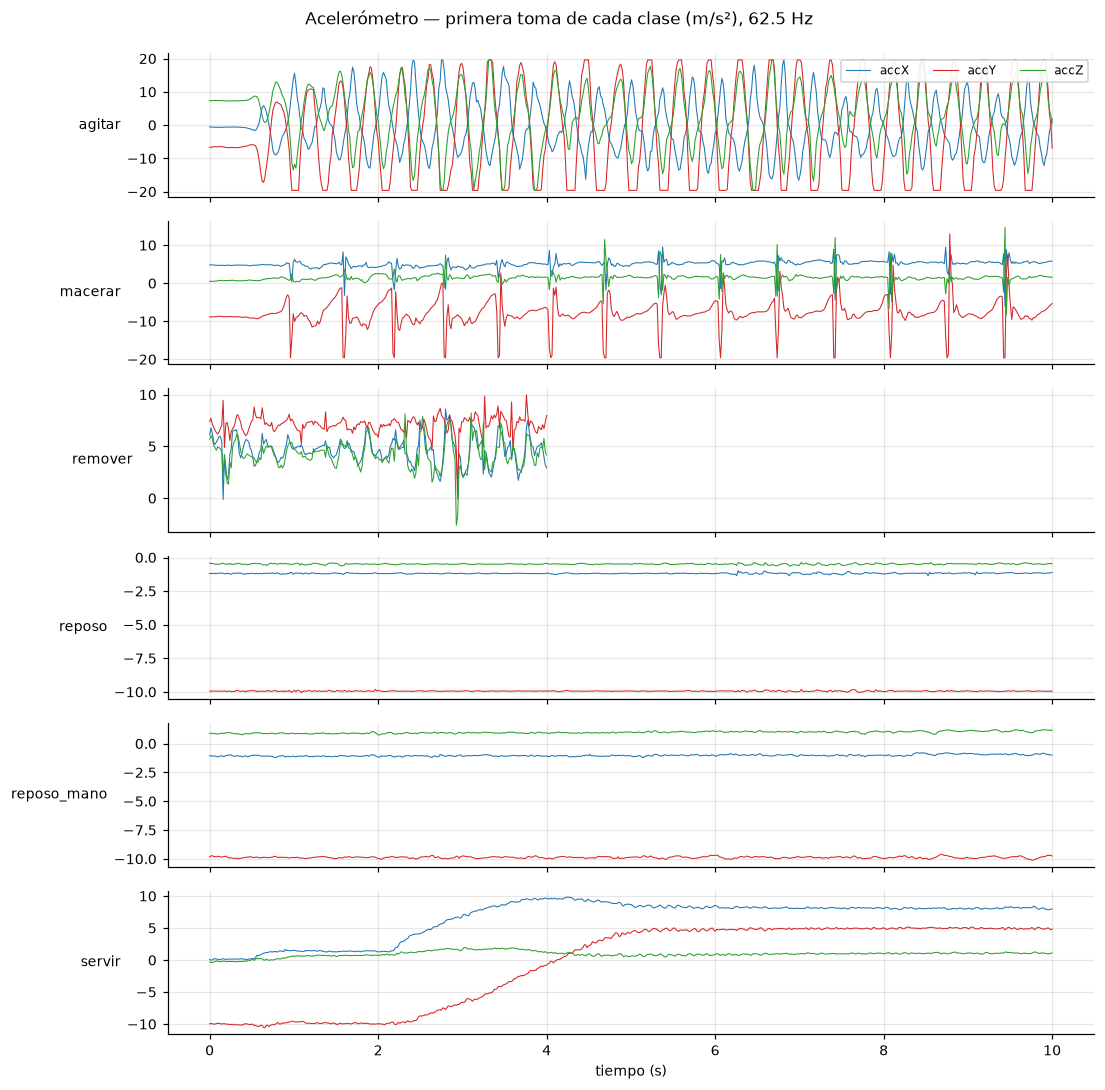

In [8]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})

COLOR = {'accX': '#1f77b4', 'accY': '#d62728', 'accZ': '#2ca02c',
         'gyrX': '#1f77b4', 'gyrY': '#d62728', 'gyrZ': '#2ca02c',
         'magX': '#1f77b4', 'magY': '#d62728', 'magZ': '#2ca02c'}

def primera_toma(clase):
    return next(t for t in tomas if t['clase'] == clase)

def panel(grupo, unidad, titulo):
    fig, axes = plt.subplots(len(CLASES), 1, figsize=(10, 1.65*len(CLASES)),
                             sharex=True)
    for ax, c in zip(axes, CLASES):
        t = primera_toma(c)
        m = selecciona_ejes(t, grupo)
        tt = np.arange(len(m))/FS
        for j, eje in enumerate(grupo):
            ax.plot(tt, m[:, j], lw=0.7, color=COLOR[eje], label=eje)
        ax.set_ylabel(c, rotation=0, ha='right', va='center', fontsize=9)
    axes[0].legend(ncol=3, loc='upper right', fontsize=8, framealpha=0.9)
    axes[-1].set_xlabel('tiempo (s)')
    fig.suptitle(f'{titulo} — primera toma de cada clase ({unidad}), {FS} Hz', y=0.995)
    fig.tight_layout(); plt.show()

panel(EJES_ACC, 'm/s²', 'Acelerómetro')


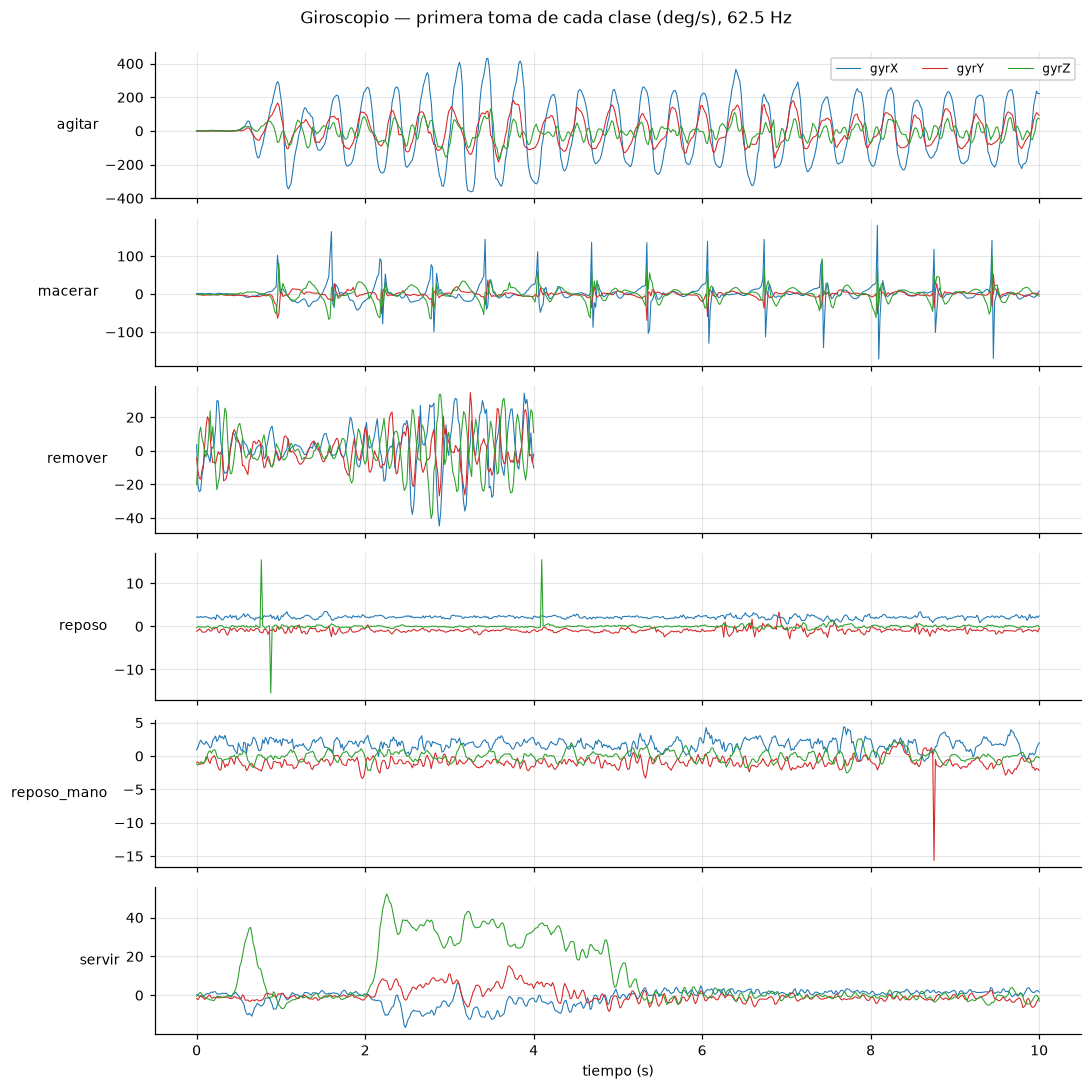

In [9]:
panel(EJES_GIR, "deg/s", "Giroscopio")


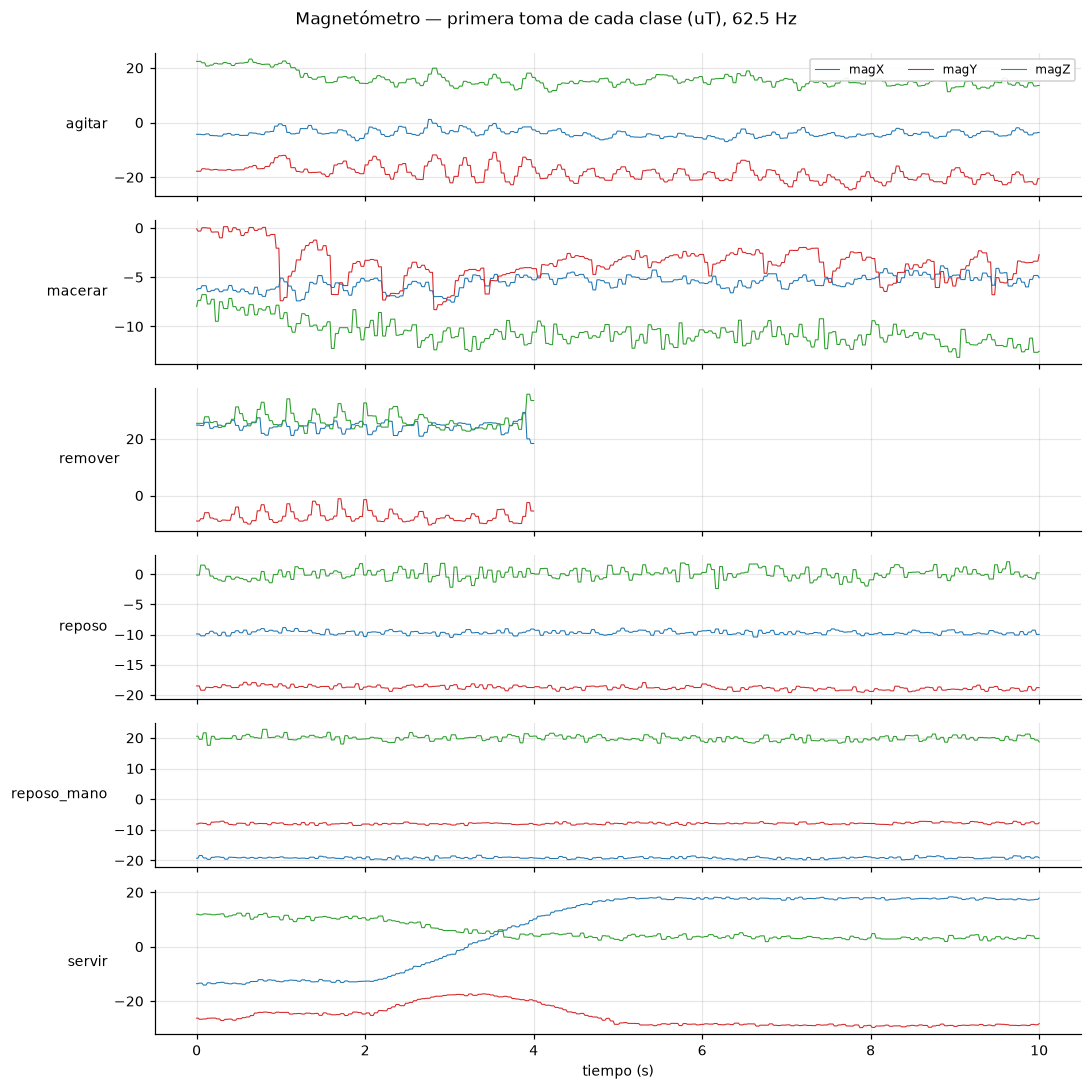

In [10]:
panel(EJES_MAG, "uT", "Magnetómetro")


> El acelerómetro separa a ojo `agitar` y `macerar` del resto; `reposo` y
> `reposo_mano` se ven **planos**, y `remover` queda en medio — con las tomas
> regrabadas del 21-sep ya tiene oscilación visible, aunque de amplitud mucho
> menor que `agitar`. El giroscopio sí separa `servir`. El magnetómetro dibuja
> líneas casi constantes: mide hacia dónde apunta la coctelera, no lo que se
> hace con ella.


## 6 · Energía por eje y por clase

Cuantifica la impresión visual. Para cada toma se calcula la desviación
estándar del módulo de cada terna de ejes (el módulo quita la dependencia de la
orientación) y se reporta la mediana sobre las 10 tomas de la clase.

In [11]:
def energia(t, ejes):
    return float(np.linalg.norm(selecciona_ejes(t, ejes), axis=1).std())

filas = []
for c in CLASES:
    ts = [t for t in tomas if t['clase'] == c]
    filas.append(dict(clase=c,
                      std_acc=np.median([energia(t, EJES_ACC) for t in ts]),
                      std_gyr=np.median([energia(t, EJES_GIR) for t in ts]),
                      std_mag=np.median([energia(t, EJES_MAG) for t in ts])))
tab_e = pd.DataFrame(filas).round(3)
print(tab_e.to_string(index=False))


      clase  std_acc  std_gyr  std_mag
     agitar    7.004   77.736    1.606
    macerar    3.273   27.962    1.084
    remover    0.645    5.934    2.059
     reposo    0.026    0.682    0.394
reposo_mano    0.062    0.916    0.592
     servir    0.244   14.496    4.675


In [12]:
# Cuánto varía cada eje ENTRE tomas de la misma clase vs entre clases.
# Si mag* separase gesto, la variación entre clases sería mucho mayor que la
# de dentro de la clase. Se mide con la razón varianza-entre / varianza-dentro.
def razon_f(ejes):
    med = {c: np.array([selecciona_ejes(t, ejes).mean(0)
                        for t in tomas if t['clase'] == c]) for c in CLASES}
    dentro = np.mean([m.var(0) for m in med.values()], axis=0)
    entre  = np.stack([m.mean(0) for m in med.values()]).var(0)
    return entre / np.maximum(dentro, 1e-9)

for nombre, ejes in [('acc', EJES_ACC), ('gyr', EJES_GIR), ('mag', EJES_MAG)]:
    r = razon_f(ejes)
    print(f'{nombre}: razón entre/dentro por eje = {np.round(r, 2)}  (media {r.mean():.2f})')


acc: razón entre/dentro por eje = [  2.11 106.45   3.88]  (media 37.48)
gyr: razón entre/dentro por eje = [1.15 0.31 6.75]  (media 2.73)
mag: razón entre/dentro por eje = [32.98  5.31  4.09]  (media 14.13)


### Decisión medida: fuera el magnetómetro

**`mag*` fuera** (issue #5). Su valor medio por clase sí es distinto — la razón
varianza-entre/varianza-dentro es alta —, pero lo que codifica es la
**orientación de la coctelera respecto al norte y el metal de alrededor**, no
el gesto: es una constante del sitio y del momento de grabación. Un modelo que
la use aprende *dónde y cuándo* se grabó, y se cae en la demo en otro salón.
En el notebook 02 se cuantifica: meter `mag*` **sube** la exactitud de 0,91 a
0,99 en el split único — y esa subida es exactamente la fuga que hay que
evitar, no aprendizaje. En la Vía B directamente **empeora** la validación
cruzada (0,987 → 0,969) y le triplica la desviación entre pliegues.

### El giroscopio: la hipótesis física, dos veces medida

A la vista de la tabla de energías parecía obvio incluirlo: `servir` tiene
`std_acc ≈ 0,24` (casi plano en acelerómetro) pero `std_gyr ≈ 14,5`, así que es
una **rotación de muñeca** y cabría esperar que sin giroscopio se perdiera.

Se probó con validación cruzada agrupada por toma en las dos vías
(notebooks 02 y 03). El resultado **depende de la vía**, y con `remover`
regrabado cambió respecto a la primera corrida:

| | solo acelerómetro (3 ejes) | acc + giroscopio (6 ejes) |
|---|--:|--:|
| Vía A (características + densa) | **0,951 ± 0,031** | 0,942 ± 0,025 |
| Vía B (Conv1D) | 0,987 ± 0,012 | **0,995 ± 0,005** |

*(Con las tomas viejas de `remover`, el giroscopio empeoraba las dos vías:
0,927 → 0,904 en A y 0,986 → 0,968 en B. La corrección de la captura es lo que
cambió el signo en la B — ver notebook 03, sección 11.)*

En la **Vía A** el giroscopio sigue empeorando: duplicar los ejes duplica las
características (39 → 78) con solo ~1000 ventanas de entrenamiento y la red de
20 neuronas se sobreajusta. En la **Vía B** ahora ayuda, poco pero de forma
consistente entre pliegues.

**Decisión para esta entrega: se entrena con los 3 ejes del acelerómetro.** Es
la configuración exportada al sketch, la que da exactamente las 39
características del PDF en la Vía A, y la diferencia en la Vía B es de +0,8 pp
sobre un 0,987 que ya basta. Pasar la B a 6 ejes queda anotado como la primera
mejora a probar **después** de la entrega.

### `remover`: regrabado el 21-sep, ya tiene movimiento

En la primera captura `remover` medía `std_acc ≈ 0,06`, del mismo orden que
`reposo` (0,03) y `reposo_mano` (0,06): tomas prácticamente estáticas, donde lo
único que las distinguía del reposo era el **vector gravedad medio** — la
orientación en la que quedó la coctelera —, no el gesto. Era un problema de
**captura**, no de modelo.

César regrabó las 10 tomas. Las nuevas miden **`std_acc` 0,645 de mediana**
(rango por toma 0,380–1,316), un orden de magnitud por encima de las viejas y
claramente por encima de `servir` (0,244). Además su frecuencia dominante sale
en **3,24 Hz con poca dispersión** (2,74–3,49 Hz entre las 10 tomas), que es lo
que se espera de un movimiento de cuchara periódico y no de ruido. La tabla de
energías de arriba y la de espectro de la sección 7 son la evidencia.

**Lo que no arregló la regrabación:** las tomas nuevas siguen durando 4 s, así
que `remover` sigue aportando 60 de 1020 ventanas (5,9 %). El issue #4 sigue
parcialmente abierto y el `class_weight` de los notebooks 02 y 03 sigue
haciendo falta.


## 7 · Espectro por clase → de aquí sale el tamaño de ventana

Se calcula la frecuencia dominante del módulo del acelerómetro (sin componente
continua) en cada toma. La ventana tiene que ser lo bastante larga para
contener varios ciclos del gesto **más lento**.

In [13]:
def frecuencia_dominante(m, fs=None, fmin=0.3):
    fs = fs or FS
    x = np.linalg.norm(m, axis=1); x = x - x.mean()
    F = np.abs(np.fft.rfft(x*np.hanning(len(x))))
    fr = np.fft.rfftfreq(len(x), 1/fs)
    sel = fr >= fmin
    return float(fr[sel][np.argmax(F[sel])])

filas = []
for c in CLASES:
    ds = [frecuencia_dominante(selecciona_ejes(t, EJES_ACC))
          for t in tomas if t['clase'] == c]
    filas.append(dict(clase=c, f_dom_mediana=np.median(ds),
                      f_min=min(ds), f_max=max(ds),
                      periodo_s=1/np.median(ds),
                      ciclos_en_2s=2.0*np.median(ds)))
print(pd.DataFrame(filas).round(2).to_string(index=False))


      clase  f_dom_mediana  f_min  f_max  periodo_s  ciclos_en_2s
     agitar           5.76   4.99   6.23       0.17         11.52
    macerar           3.19   1.30   5.89       0.31          6.39
    remover           3.24   2.74   3.49       0.31          6.47
     reposo           3.69   3.19   6.99       0.27          7.39
reposo_mano           3.44   2.30   7.99       0.29          6.89
     servir           1.90   1.40   3.00       0.53          3.79


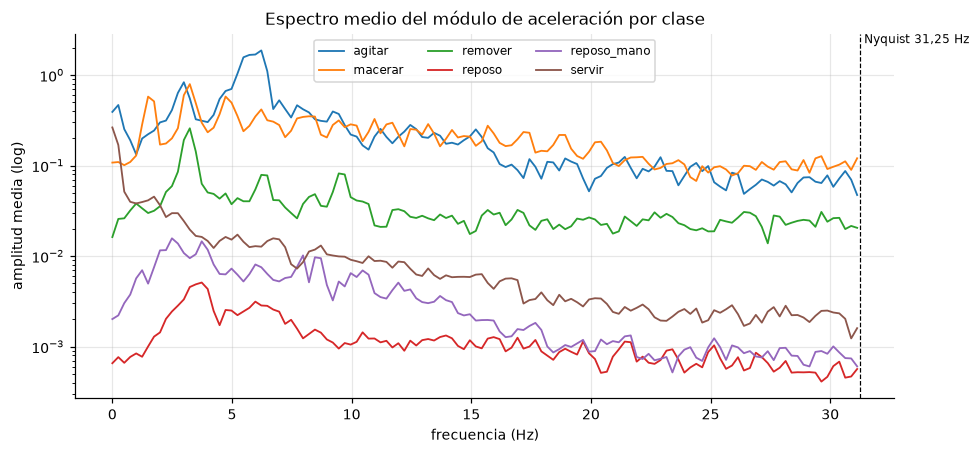

In [14]:
# Espectro medio por clase (acelerómetro, módulo sin DC)
fig, ax = plt.subplots(figsize=(9, 4.2))
for c in CLASES:
    acum = None
    for t in [t for t in tomas if t['clase'] == c]:
        x = np.linalg.norm(selecciona_ejes(t, EJES_ACC), axis=1); x = x - x.mean()
        n = 251                                   # recorte común: la toma más corta
        x = x[:n]
        F = np.abs(np.fft.rfft(x*np.hanning(n)))*2/n
        acum = F if acum is None else acum + F
    fr = np.fft.rfftfreq(n, 1/FS)
    ax.semilogy(fr, acum/10 + 1e-6, lw=1.2, label=c)
ax.axvline(FS/2, ls='--', c='k', lw=0.8)
ax.text(FS/2, ax.get_ylim()[1], ' Nyquist 31,25 Hz', va='top', fontsize=8)
ax.set_xlabel('frecuencia (Hz)'); ax.set_ylabel('amplitud media (log)')
ax.set_title('Espectro medio del módulo de aceleración por clase')
ax.legend(ncol=3, fontsize=8); fig.tight_layout(); plt.show()


### Elección de la ventana: **125 muestras = 2,00 s**, paso 25 (80 % de solape)

Razones, todas apoyadas en lo medido arriba:

1. **125 muestras son 2,00 s a 62,5 Hz.** El ejemplo de clase usaba
   `ventana=100` a 100 Hz, que allí era 1,0 s; copiar ese 100 aquí daría 1,6 s.
   El número que corresponde a 2 s en *nuestro* muestreo es 125.
2. **Cabe el gesto más lento.** `servir` tiene f dominante ≈ 1,9 Hz (periodo
   0,53 s): en 2 s entran ~3,8 ciclos. `agitar` (≈5,8 Hz) entra ~11 veces.
   Con 1 s `servir` daría menos de 2 ciclos.
3. **Cabe en la toma más corta.** Las tomas de `remover` y de 6 de las de
   `agitar` duran 4,016 s (251 muestras): con W=125 caben 6 ventanas por toma a
   paso 25; con W=200 cabrían 3 y con W=251 solo 1.
4. **Nyquist.** 62,5 Hz muestrea hasta 31,25 Hz. Toda la energía útil de los
   gestos está por debajo de 12 Hz, así que el muestreo no es el cuello de
   botella; la resolución espectral de la ventana, 1/2 s = 0,5 Hz, sí basta para
   separar 1,9 Hz de 5,8 Hz.
5. **Paso 25 (0,4 s) en vez de 62.** Con paso 62 (50 % de solape, como en clase)
   salen 444 ventanas en total y solo 30 de `remover`: demasiado poco. Con paso
   25 salen ~1020. El solape alto **no** infla la métrica porque el split es
   **por toma**: dos ventanas solapadas son siempre del mismo lado de la
   partición. En el notebook 02 se compara W ∈ {64, 96, 125} de forma empírica.

En inferencia esto significa: el Nano clasifica con **2 s de contexto** y puede
emitir una predicción cada 0,4 s si se mantiene el mismo paso.

## 8 · Cuántas ventanas aporta cada clase (issue #4)

Esta es la medición que pide la tarea. Se recorren varias combinaciones de
ventana y paso para ver el desbalance en cada una.

In [15]:
def conteo_ventanas(W, S):
    _, y, g = ventanear(tomas, EJES_USADOS, W, S)
    c = pd.Series(y).value_counts().reindex(CLASES).fillna(0).astype(int)
    return c

confs = [(125, 25), (125, 62), (100, 50), (96, 24), (64, 16)]
tab = pd.DataFrame({f'W={W} ({W/FS:.2f}s) S={S}': conteo_ventanas(W, S)
                    for W, S in confs})
tab.loc['TOTAL'] = tab.sum()
print(tab.to_string())
print()
for col in tab.columns:
    v = tab[col].drop('TOTAL')
    print(f'{col:22s} total={int(v.sum()):5d}  '
          f'min={v.idxmin()} ({int(v.min())})  max={v.idxmax()} ({int(v.max())})  '
          f'desbalance max/min = {v.max()/max(v.min(),1):.2f}×')


             W=125 (2.00s) S=25  W=125 (2.00s) S=62  W=100 (1.60s) S=50  W=96 (1.54s) S=24  W=64 (1.02s) S=16
agitar                      120                  54                  68                134                216
macerar                     210                  90                 110                230                360
remover                      60                  30                  40                 70                120
reposo                      210                  90                 110                230                360
reposo_mano                 210                  90                 110                230                360
servir                      210                  90                 110                230                360
TOTAL                      1020                 444                 548               1124               1776

W=125 (2.00s) S=25     total= 1020  min=remover (60)  max=macerar (210)  desbalance max/min = 3.50×
W=125 (2.00s) S=62 

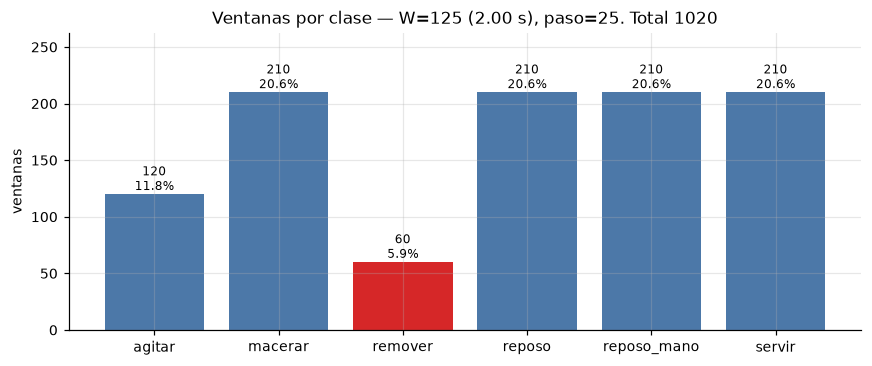

             ventanas  porcentaje  vs_clase_mayor
agitar            120        11.8            1.75
macerar           210        20.6            1.00
remover            60         5.9            3.50
reposo            210        20.6            1.00
reposo_mano       210        20.6            1.00
servir            210        20.6            1.00


In [16]:
# Reparto porcentual con la configuración elegida
W_EL, S_EL = 125, 25
c = conteo_ventanas(W_EL, S_EL)
pct = 100*c/c.sum()
fig, ax = plt.subplots(figsize=(8, 3.4))
b = ax.bar(CLASES, c.values, color=['#d62728' if x == c.min() else '#4c78a8' for x in c.values])
for r, n, p in zip(b, c.values, pct.values):
    ax.text(r.get_x()+r.get_width()/2, n, f'{n}\n{p:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('ventanas'); ax.set_ylim(0, c.max()*1.25)
ax.set_title(f'Ventanas por clase — W={W_EL} ({W_EL/FS:.2f} s), paso={S_EL}. '
             f'Total {int(c.sum())}')
fig.tight_layout(); plt.show()
print(pd.DataFrame({'ventanas': c, 'porcentaje': pct.round(1),
                    'vs_clase_mayor': (c.max()/c).round(2)}).to_string())


### Cuánto desbalancea `remover` — respuesta medida

Con la configuración elegida (**W = 125, paso = 25**):

| clase | ventanas | % del total | veces menos que la clase mayor |
|---|--:|--:|--:|
| `agitar` | 120 | 11,8 % | 1,75× |
| `macerar` | 210 | 20,6 % | 1,00× |
| **`remover`** | **60** | **5,9 %** | **3,50×** |
| `reposo` | 210 | 20,6 % | 1,00× |
| `reposo_mano` | 210 | 20,6 % | 1,00× |
| `servir` | 210 | 20,6 % | 1,00× |
| **total** | **1020** | | |

*(Los valores exactos los imprime la celda anterior; esta tabla es la corrida
del 21-sep-2026 sobre las 60 tomas del repo.)*

`remover` aporta **60 ventanas de 1020 — el 5,9 %** — frente al 20,6 % de cada
clase larga: **3,5 veces menos**. La causa es directa: `remover` son 40,2 s de
grabación contra 100,2 s de las otras, y el número de ventanas sale
proporcional a los **segundos**, no al número de tomas. Un clasificador
entrenado sin corregir esto tiende a no predecir nunca `remover`, y la
exactitud global apenas lo nota porque `remover` pesa poco en la media.

**Qué se hace al respecto en los notebooks 02 y 03:**

1. `class_weight` inversamente proporcional a la frecuencia, para que el error
   en `remover` pese como el de las clases grandes.
2. Se reporta **matriz de confusión y recall por clase**, no solo la exactitud
   global — es la única forma de ver el fallo de `remover`.

**Qué se hizo y qué sigue pendiente.** El 21-sep se regrabaron las 10 tomas de
`remover` *con el gesto realmente ejecutado* (sección 6), lo que arregló el
problema de señal plana. Pero las tomas nuevas **siguen durando 4 s**, así que
el desbalance de esta tabla **no cambió**: `remover` sigue siendo 60 de 1020
ventanas. Para cerrar el issue #4 habría que capturarlas de 10 s como el resto.
Y siguen faltando las 10 tomas de `colar` (issue #2).

## 9 · Resumen de lo medido

| Hecho medido | Valor | Consecuencia |
|---|---|---|
| `interval_ms` en las 60 tomas | 16,0 | **fs = 62,5 Hz**; 2 s = **125 muestras** |
| Tomas / clases | 60 / 6 (10 por clase) | falta `colar` → requisito 2 sin cumplir (issue #2) |
| Duración total | 504,96 s | |
| Duración de `remover` | 40,16 s vs 100,16 s de las largas (las tomas nuevas también son de 4 s) | 3,5× menos ventanas — issue #4 **sigue abierto** |
| Ventanas con W=125, S=25 | 1020, de las que `remover` son 60 (5,9 %) | `class_weight` + métricas por clase |
| `std_acc` de `remover` (regrabado 21-sep) | **0,645** de mediana (0,380–1,316 por toma), contra 0,06 de la captura vieja | movimiento real capturado; el recall en CV sube de 0,90 a **1,00** en la Vía B |
| `std_gyr` de `servir` | 14,5 con `std_acc` 0,24 | con las tomas nuevas el giroscopio **empeora la Vía A** (0,951→0,942) y **mejora la Vía B** (0,987→0,995); se entrega con **3 ejes** y queda anotado — ver sección 6 |
| `mag*` | varía por orientación, no por gesto | fuera del modelo (issue #5) |
| Split | por **toma**, 60 grupos | GroupShuffleSplit en 02 y 03 (issue #3) |

Siguiente paso: [`02_entrenamiento_A_caracteristicas.ipynb`](02_entrenamiento_A_caracteristicas.ipynb)
y [`03_entrenamiento_B_conv1d.ipynb`](03_entrenamiento_B_conv1d.ipynb).